In [2]:
import seaborn as sns

tips = sns.load_dataset('tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
q1 = tips['tip'].quantile(0.25) 
q3 = tips['tip'].quantile(0.75)
print(q1)
print(q3)

2.0
3.5625


In [12]:
iqr = q3 - q1
print(iqr)
lower = q1 - (1.5 * iqr)
upper = q3 + (1.5 * iqr)
print(lower)
print(upper)

1.5625
-0.34375
5.90625


In [15]:
outliers = tips[(tips['tip'] < lower) | (tips['tip'] > upper)]
print(outliers)
print(tips.shape)

     total_bill    tip     sex smoker   day    time  size
23        39.42   7.58    Male     No   Sat  Dinner     4
47        32.40   6.00    Male     No   Sun  Dinner     4
59        48.27   6.73    Male     No   Sat  Dinner     4
141       34.30   6.70    Male     No  Thur   Lunch     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
183       23.17   6.50    Male    Yes   Sun  Dinner     4
212       48.33   9.00    Male     No   Sat  Dinner     4
214       28.17   6.50  Female    Yes   Sat  Dinner     3
239       29.03   5.92    Male     No   Sat  Dinner     3
(244, 7)


In [14]:
tips_inline = tips[(tips['tip'] >= lower) & (tips['tip'] <= upper)]
tips_inline.shape

(235, 7)

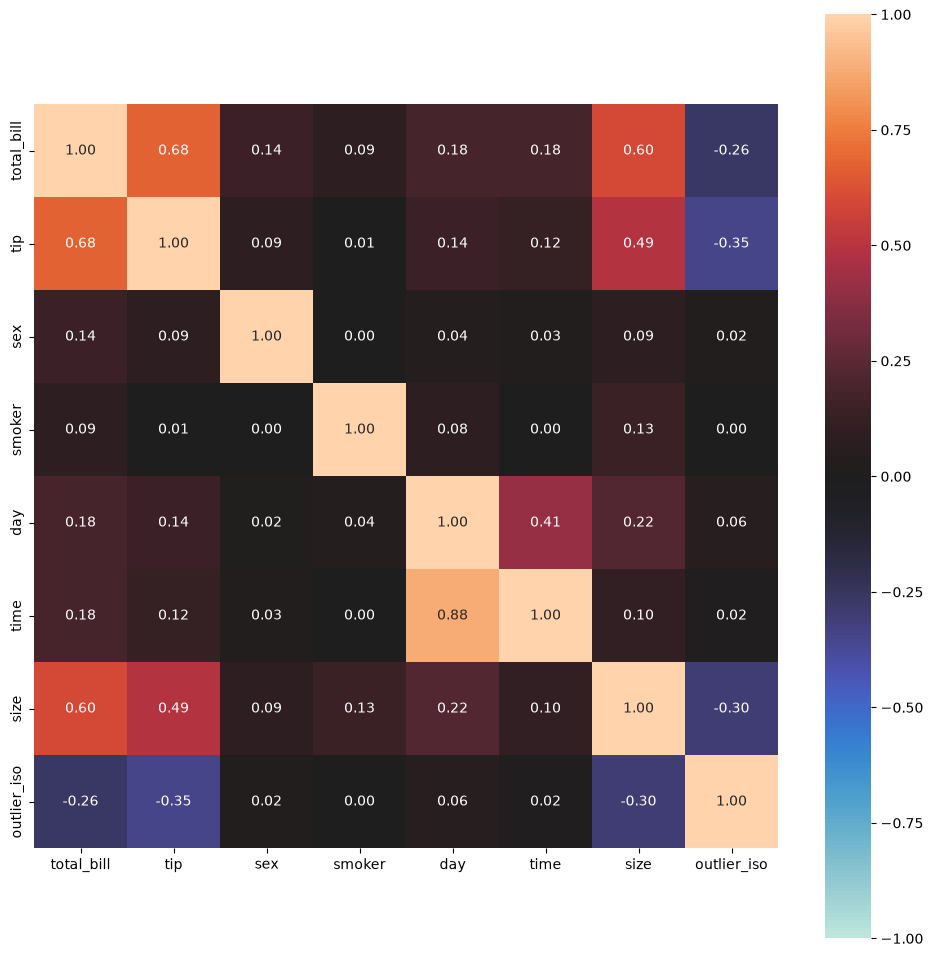

In [26]:
from dython.nominal import associations
import matplotlib.pyplot as plt
result = associations(tips, 
             nominal_columns='auto', 
             nom_nom_assoc='theil',
             num_num_assoc='pearson'
            )
plt.show()

In [27]:
from sklearn.ensemble import IsolationForest
import numpy as np

In [28]:
SEED = 42
X_outlier = tips.select_dtypes(np.number).copy()
iso = IsolationForest(contamination=0.05, n_estimators=100, random_state=SEED)
tips['outlier_iso'] = iso.fit_predict(X_outlier)
tips.head()

,total_bill,tip,sex,smoker,day,time,size,outlier_iso
0,16.99,1.01,Female,No,Sun,Dinner,2,1
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1
4,24.59,3.61,Female,No,Sun,Dinner,4,1


In [29]:
print((tips['outlier_iso'] == -1).sum())

13


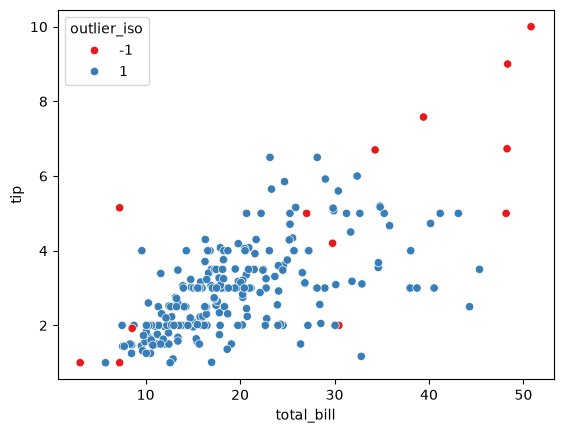

In [30]:
sns.scatterplot(tips, x=tips['total_bill'], y=tips['tip'], hue=tips['outlier_iso'], palette='Set1')
plt.show()